[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/doxav/astromodel_proving/blob/main/analysis/08_parameter_plausibility_and_constrained_reruns.ipynb)

# Step 08 — Parameter plausibility and constrained reruns

This notebook runs the local Step 08 pipeline without Google Drive dependencies and writes auditable outputs under `outputs/parameter_plausibility/`.

**Claim scope:** Step 08 audits whether accepted parameters are plausible and interpretable. It does not authorize final biological degeneracy wording because Step 09 synthesis is still pending.

In [1]:
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(os.environ.get("ASTROMODEL_PROJECT_ROOT", ".")).resolve()
PROJECT_ROOT

PosixPath('/workspace/astromodel_proving')

In [2]:
from src.step08_parameter_plausibility import (
    Step08Config,
    compare_step08_runtime_presets,
    run_step08_parameter_plausibility,
)

config = Step08Config(max_candidates=3, write_outputs=True)
result = run_step08_parameter_plausibility(PROJECT_ROOT, config)
result["analysis_summary"]

{'step': '08_parameter_plausibility_and_constrained_reruns',
 'config': {'max_candidates': 3,
  'constrained_max_candidates': 3,
  'time_points': 40,
  't_final_ms': 50000.0,
  'currents_na': (50, 75, 100, 125, 150, 175),
  'min_holdout_pass_fraction': 0.3,
  'max_trace_rmse_mV': 25.0,
  'boundary_fraction': 0.05,
  'acceptable_fit_degradation_fraction': 0.15,
  'mechanism_flux_fraction_delta_max': 0.2,
  'changed_fit_degradation_warn_mV': 5.0,
  'write_outputs': True},
 'n_candidates': 3,
 'n_parameter_rows': 27,
 'n_effective_rows': 12,
 'n_out_of_range_rows': 0,
 'n_phys_interpretable_rows': 9,
 'n_constrained_rerun_rows': 18,
 'currents_na': [50, 75, 100, 125, 150, 175],
 'final_degeneracy_claim_allowed_after_step08': False,
 'claim_scope': 'Step 08 supports parameter-interpretability guardrails, but final biological degeneracy claims remain disabled until Step 09 synthesis.'}

## 1. Accepted ensemble inventory

The Step 08 input contract preserves the same cell/candidate identity, brain region, condition, held-out metrics, and mechanism labels used by Steps 05–07.

In [3]:
inventory_cols = [
    "file_id", "region", "condition", "candidate_id", "mechanism_cluster", "dominant_mechanism",
    "holdout_mean_rmse_mV", "holdout_mean_pass_fraction",
]
inventory = result["candidates"][inventory_cols].copy()
inventory

,file_id,region,condition,candidate_id,mechanism_cluster,dominant_mechanism,holdout_mean_rmse_mV,holdout_mean_pass_fraction
0,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,M1,Mixed,12.419387,0.340218
1,1_DH_1,DH,CONTROL,1_DH_1__cand_02__low_gap,M1,Mixed,12.419387,0.340218
2,1_DH_1,DH,CONTROL,1_DH_1__cand_03__high_gap,M1,Mixed,12.419387,0.340218


## 2. Parameter plausibility and identifiability audit

Each candidate × parameter row receives a plausibility status, an identifiability status from Step 03 where available, and an explicit interpretation guardrail.

In [4]:
audit = result["parameter_range_audit"]
display_cols = [
    "file_id", "region", "condition", "candidate_id", "parameter", "coordinate_type", "value",
    "plausibility_status", "identifiability_status", "physiologically_interpretable", "interpretation_guardrail",
]
audit[display_cols].head(20)

,file_id,region,condition,candidate_id,parameter,coordinate_type,value,plausibility_status,identifiability_status,physiologically_interpretable,interpretation_guardrail
0,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,gki,raw,60.750000,within_range,identifiable,True,within broad range and supported by available ...
1,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,eps,raw,0.013500,within_range,identifiable,True,within broad range and supported by available ...
2,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,gl_a,raw,0.010000,within_range,identifiable,True,within broad range and supported by available ...
3,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,zth,raw,0.200000,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
4,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,zs,raw,0.050000,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
5,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,P_gap_eff,effective,0.000450,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
6,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,gamma_t_eff,effective,0.000050,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
7,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,gamma_s_eff,effective,0.000056,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
8,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,volume_ratio_wa_wo,effective,1.000000,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
9,1_DH_1,DH,CONTROL,1_DH_1__cand_02__low_gap,gki,raw,60.750000,within_range,identifiable,True,within broad range and supported by available ...


In [5]:
status_counts = (
    audit.groupby(["coordinate_type", "plausibility_status", "identifiability_status"], dropna=False)
    .size()
    .rename("n_rows")
    .reset_index()
)
status_counts

,coordinate_type,plausibility_status,identifiability_status,n_rows
0,effective,within_range,weakly_identified,12
1,raw,within_range,identifiable,9
2,raw,within_range,weakly_identified,6


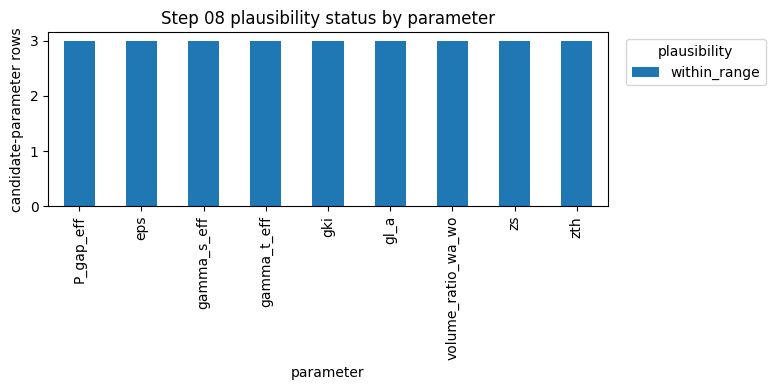

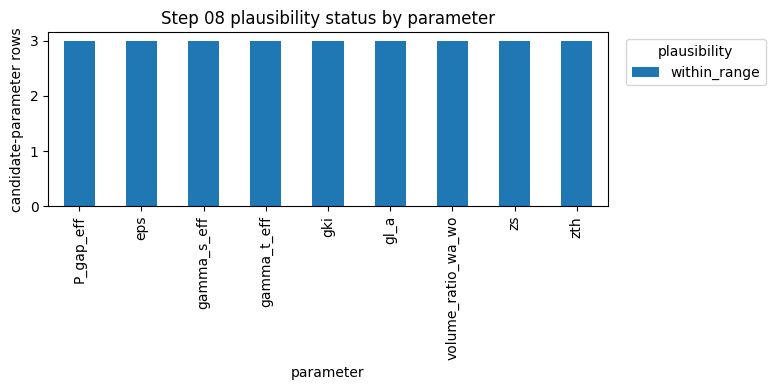

In [6]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_data = audit.groupby(["parameter", "plausibility_status"]).size().unstack(fill_value=0)
plot_data.plot(kind="bar", stacked=True, ax=ax)
ax.set_ylabel("candidate-parameter rows")
ax.set_title("Step 08 plausibility status by parameter")
ax.legend(title="plausibility", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig

## 3. Effective-parameter plausibility

Effective coordinates are exported separately because they are the preferred reviewer-facing representation for structurally confounded raw factors.

In [7]:
effective = result["effective_parameter_plausibility"]
effective.head(20)

,file_id,region,condition,candidate_id,mechanism_cluster,dominant_mechanism,parameter,value,lower_bound,upper_bound,plausibility_status,identifiability_status,physiologically_interpretable,interpretation_guardrail
0,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,M1,Mixed,P_gap_eff,0.000450,1.000000e-08,0.005,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
1,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,M1,Mixed,gamma_t_eff,0.000050,1.000000e-08,0.050,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
2,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,M1,Mixed,gamma_s_eff,0.000056,1.000000e-08,0.050,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
3,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,M1,Mixed,volume_ratio_wa_wo,1.000000,1.000000e-03,1000.000,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
4,1_DH_1,DH,CONTROL,1_DH_1__cand_02__low_gap,M1,Mixed,P_gap_eff,0.000315,1.000000e-08,0.005,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
5,1_DH_1,DH,CONTROL,1_DH_1__cand_02__low_gap,M1,Mixed,gamma_t_eff,0.000050,1.000000e-08,0.050,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
6,1_DH_1,DH,CONTROL,1_DH_1__cand_02__low_gap,M1,Mixed,gamma_s_eff,0.000056,1.000000e-08,0.050,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
7,1_DH_1,DH,CONTROL,1_DH_1__cand_02__low_gap,M1,Mixed,volume_ratio_wa_wo,1.000000,1.000000e-03,1000.000,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
8,1_DH_1,DH,CONTROL,1_DH_1__cand_03__high_gap,M1,Mixed,P_gap_eff,0.000585,1.000000e-08,0.005,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...
9,1_DH_1,DH,CONTROL,1_DH_1__cand_03__high_gap,M1,Mixed,gamma_t_eff,0.000050,1.000000e-08,0.050,within_range,weakly_identified,False,within broad range but Step 03 indicates weak/...


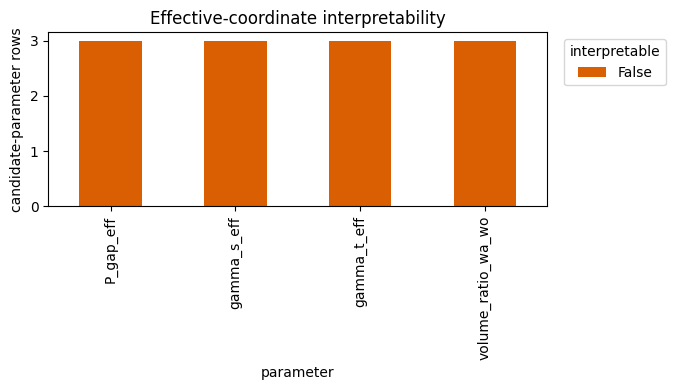

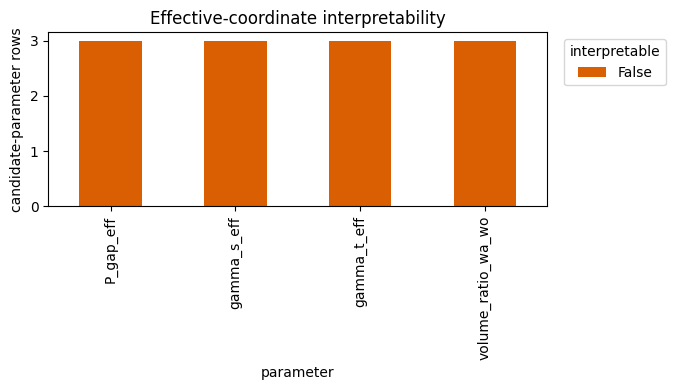

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
eff_plot = effective.groupby(["parameter", "physiologically_interpretable"]).size().unstack(fill_value=0)
eff_plot.plot(kind="bar", stacked=True, ax=ax, color=["#d95f02", "#1b9e77"])
ax.set_ylabel("candidate-parameter rows")
ax.set_title("Effective-coordinate interpretability")
ax.legend(title="interpretable", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig

## 4. Constrained rerun comparison

The constrained screen projects parameters into broad plausibility ranges and compares held-out prediction and mechanism-persistence status. This is an auditable screen, not a replacement optimizer.

In [9]:
constrained = result["constrained_rerun_comparison"]
constrained

,file_id,region,condition,candidate_id,mechanism_cluster,dominant_mechanism,mechanism_cluster_unconstrained,constrained_screen_type,changed_by_constraints,changed_parameters,...,prediction_persists_under_constraints,dominant_mechanism_unconstrained,dominant_mechanism_constrained,mechanism_flux_fraction_delta_max,mechanism_changed_under_constraints,mechanism_cluster_constrained,mechanism_persists_under_constraints,mechanism_conclusion_persists,constrained_claim_status,constraint_action
0,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,M1,Mixed,M1,broad_range_projection_not_full_optimizer,False,,...,True,gap,gap,0.0,False,M1,True,True,claim_persists_under_broad_constraints,not_required
1,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,M1,Mixed,M1,broad_range_projection_not_full_optimizer,False,,...,True,gap,gap,0.0,False,M1,True,True,claim_persists_under_broad_constraints,not_required
2,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,M1,Mixed,M1,broad_range_projection_not_full_optimizer,False,,...,True,gap,gap,0.0,False,M1,True,True,claim_persists_under_broad_constraints,not_required
3,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,M1,Mixed,M1,broad_range_projection_not_full_optimizer,False,,...,True,gap,gap,0.0,False,M1,True,True,claim_persists_under_broad_constraints,not_required
4,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,M1,Mixed,M1,broad_range_projection_not_full_optimizer,False,,...,True,gap,gap,0.0,False,M1,True,True,claim_persists_under_broad_constraints,not_required
5,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,M1,Mixed,M1,broad_range_projection_not_full_optimizer,False,,...,True,gap,gap,0.0,False,M1,True,True,claim_persists_under_broad_constraints,not_required
6,1_DH_1,DH,CONTROL,1_DH_1__cand_02__low_gap,M1,Mixed,M1,broad_range_projection_not_full_optimizer,False,,...,True,gap,gap,0.0,False,M1,True,True,claim_persists_under_broad_constraints,not_required
7,1_DH_1,DH,CONTROL,1_DH_1__cand_02__low_gap,M1,Mixed,M1,broad_range_projection_not_full_optimizer,False,,...,True,gap,gap,0.0,False,M1,True,True,claim_persists_under_broad_constraints,not_required
8,1_DH_1,DH,CONTROL,1_DH_1__cand_02__low_gap,M1,Mixed,M1,broad_range_projection_not_full_optimizer,False,,...,True,gap,gap,0.0,False,M1,True,True,claim_persists_under_broad_constraints,not_required
9,1_DH_1,DH,CONTROL,1_DH_1__cand_02__low_gap,M1,Mixed,M1,broad_range_projection_not_full_optimizer,False,,...,True,gap,gap,0.0,False,M1,True,True,claim_persists_under_broad_constraints,not_required


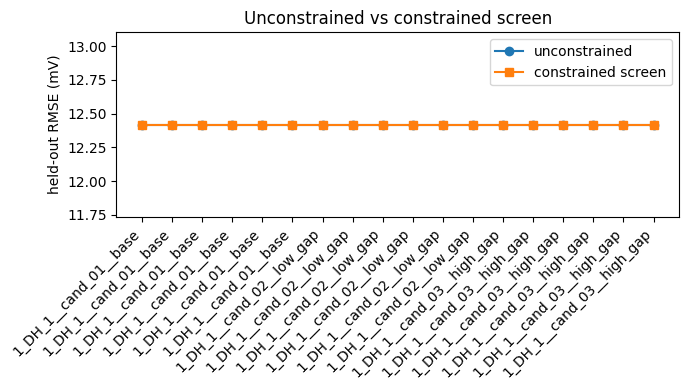

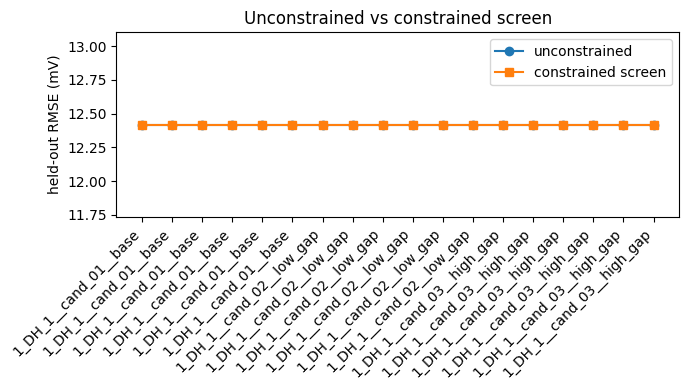

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
if not constrained.empty:
    x = range(len(constrained))
    ax.plot(x, constrained["unconstrained_holdout_rmse_mV"], marker="o", label="unconstrained")
    ax.plot(x, constrained["constrained_holdout_rmse_mV"], marker="s", label="constrained screen")
    ax.set_xticks(list(x))
    ax.set_xticklabels(constrained["candidate_id"], rotation=45, ha="right")
ax.set_ylabel("held-out RMSE (mV)")
ax.set_title("Unconstrained vs constrained screen")
ax.legend()
fig.tight_layout()
fig

## 5. Candidate-level interpretability status

Candidate-level rows combine plausibility, identifiability, and constrained-screen persistence into conservative claim statuses.

In [11]:
status = result["interpretability_status"]
status

,file_id,region,condition,candidate_id,mechanism_cluster,dominant_mechanism,n_parameters_audited,n_out_of_range,n_weakly_identified,n_effective_only,n_phys_interpretable,prediction_persists_under_constraints,mechanism_persists_under_constraints,n_constrained_current_rows,max_mechanism_flux_fraction_delta,constrained_claim_status,parameter_interpretability_status,parameter_claim_allowed_after_step08,final_degeneracy_claim_allowed_after_step08,claim_scope_note
0,1_DH_1,DH,CONTROL,1_DH_1__cand_01__base,M1,Mixed,9,0,6,0,3,True,True,6,0.0,claim_persists_under_broad_constraints,partial_effective_or_weak_identifiability_only,True,False,Step 08 supports parameter-interpretability gu...
1,1_DH_1,DH,CONTROL,1_DH_1__cand_02__low_gap,M1,Mixed,9,0,6,0,3,True,True,6,0.0,claim_persists_under_broad_constraints,partial_effective_or_weak_identifiability_only,True,False,Step 08 supports parameter-interpretability gu...
2,1_DH_1,DH,CONTROL,1_DH_1__cand_03__high_gap,M1,Mixed,9,0,6,0,3,True,True,6,0.0,claim_persists_under_broad_constraints,partial_effective_or_weak_identifiability_only,True,False,Step 08 supports parameter-interpretability gu...


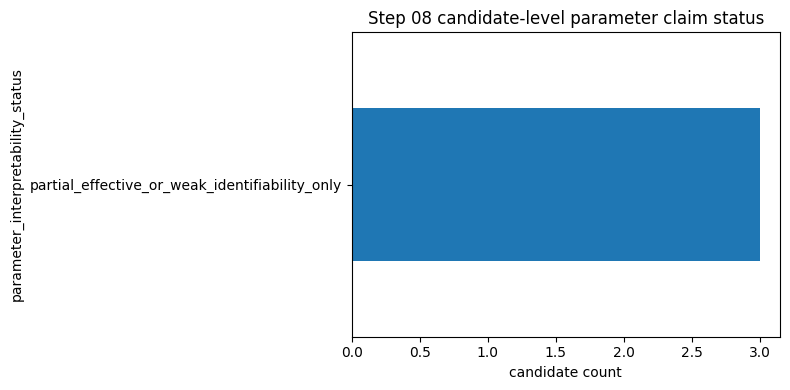

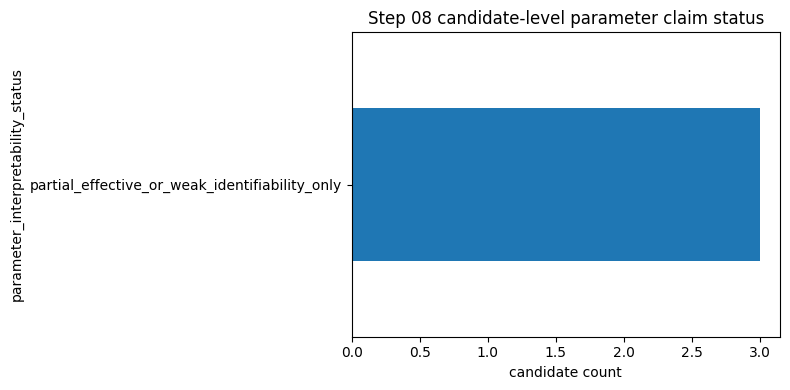

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
claim_counts = status["parameter_interpretability_status"].value_counts().sort_index()
claim_counts.plot(kind="barh", ax=ax)
ax.set_xlabel("candidate count")
ax.set_title("Step 08 candidate-level parameter claim status")
fig.tight_layout()
fig

## 6. Performance tuning

A small runtime comparison documents whether the default notebook setting remains practical.

In [13]:
performance = compare_step08_runtime_presets(PROJECT_ROOT, max_candidates=1)
output_dir = PROJECT_ROOT / "outputs" / "parameter_plausibility"
output_dir.mkdir(parents=True, exist_ok=True)
performance.to_csv(output_dir / "performance_benchmark.csv", index=False)
performance

,preset,max_candidates,elapsed_seconds,n_parameter_rows,tuning_recommendation
0,coarse,1,0.880206,9,use_default_for_notebook
1,default,2,1.616826,18,use_default_for_notebook


## Conservative conclusion

Step 08 permits cautious statements about which accepted coordinates are within broad plausibility ranges and which are interpretable only as effective parameters. Final biological degeneracy claims remain disabled until Step 09 integrates provenance, assumptions, predictions, parameter plausibility, and manuscript-facing tables.

In [14]:
summary_path = PROJECT_ROOT / "outputs" / "parameter_plausibility" / "analysis_summary.json"
print(summary_path)
print(result["analysis_summary"]["claim_scope"])

/workspace/astromodel_proving/outputs/parameter_plausibility/analysis_summary.json
Step 08 supports parameter-interpretability guardrails, but final biological degeneracy claims remain disabled until Step 09 synthesis.
